# Objectives

##  Compare the definition of best matches and weak best matches

### Check whether every best match in $(N, \sigma)$ is also a weak best match. Test this computationally, but also try to give a formal argument.

Wie bereits in der Aufgabenstellung beschrieben, erstellen wir ein neues Set, welches die Menge aller last common ancestors zwischen einem bestimmten Blatt und einer anderen Farbe darstellt.
Für alle $x \in L(N)$ und $\tau \in \sigma(L(N)\backslash x)$ definieren wir:
$$Q(x,\tau) \coloneqq \min_{\preceq} \{v\in lca(x,y):\sigma(y) = \tau\}$$
Für die *weak* best matches haben wir dabei bereits folgendes definiert: Gilt für ein Netzwerk $N$: $x,y\in L(N), \, \sigma (y) \ne \sigma(x)$, dann ist $y$ ein *weak* best match von $x$ wenn gilt: $lca(x,y) \cap Q(x,\sigma(y)) \ne \varnothing$.

Die Anforderung ist also, dass die Menge der last common ancestors von x und y eine Schnittmenge bildet mit der Menge Q.

Für die *strong* best matches definieren wir: Gilt für ein Netzwerk $N$: $x,y\in L(N), \, \sigma (y) \ne \sigma(x)$, dann ist $y$ ein *strong* best match von $x$ wenn gilt: $LCA(x,y) \subseteq Q(x,\sigma(y))$ und $u \nprec v \, \forall u \in Q(x,\sigma(y)), \forall v\in LCA (x,y)$. Sprich, es gilt die Bedingung für weak best matches, und die Zusatzbedingung dass die Menge der last common ancestors keine Node enthalten dürfen, die über irgendeiner node in Q liegt.

Die formale Definition zeigt direkt, dass alle strong best matches auch weak best matches sind, aber dass das nicht zwingend umgekehrt gelten muss. 

Beispiel aus dem Netzwerk paper, welches zeigt dass strong best matches auch weak best matches sind, aber nicht umgekehrt.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg
from BICcherryRestrict import BICcherryRestrict
from BICcherry_reverse import BICcherry_reverse

In [23]:
test_graph = nx.DiGraph()
test_graph.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"})])
test_graph.add_edges_from([("rho", "p1"), ("rho", "p2"), ("p1", "y2"), ("p1", "p3"), ("p2" ,"p3"),
                           ("p2", "x1"), ("p3", "x2"), ("p3", "y1")])

test_BMG = nx.DiGraph()
test_BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
test_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x1", "y3"), ("y3", "x1"),
                        ("x2", "y2"), ("y2", "x1"), ("x2", "y1")])
"""
test_BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("z1", {"color": "green"})])
test_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x2", "y1"), ("y2", "x2"),
                        ("x1", "z1"), ("y1", "z1"), ("x2", "z1"), ("y2", "z1"),
                        ("z1", "x1"), ("z1", "y1"), ("z1", "x2"), ("z1", "y2")])"""

'\ntest_BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("z1", {"color": "green"})])\ntest_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x2", "y1"), ("y2", "x2"),\n                        ("x1", "z1"), ("y1", "z1"), ("x2", "z1"), ("y2", "z1"),\n                        ("z1", "x1"), ("z1", "y1"), ("z1", "x2"), ("z1", "y2")])'

Text(0.5, 1.0, 'Weak BMG')

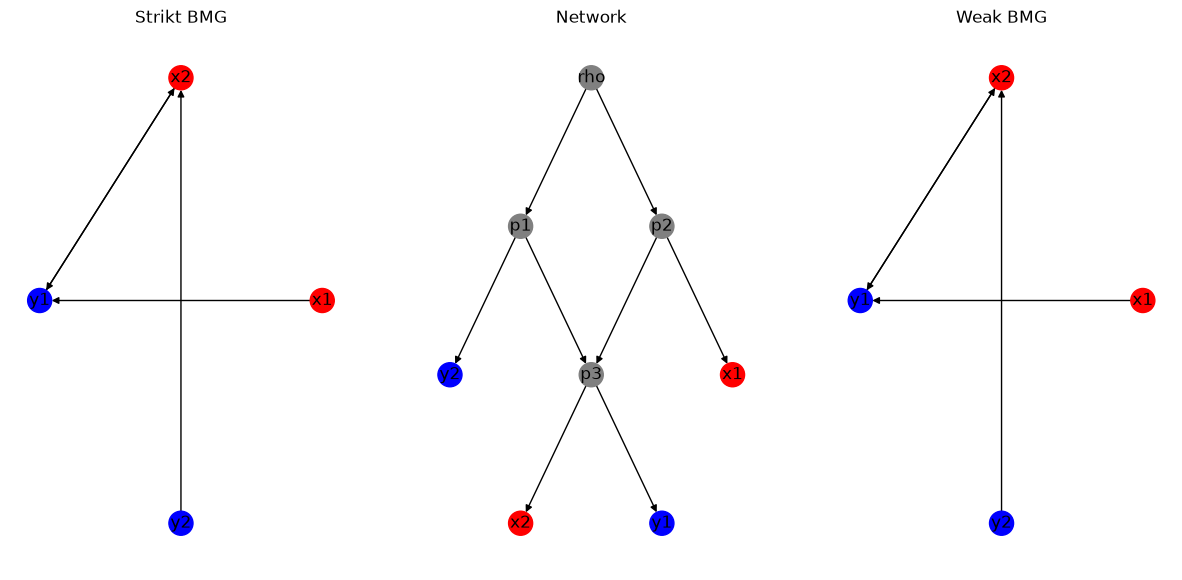

In [3]:
# figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
pos = graphviz_layout(test_graph, prog="dot")
nodes_list, nodes_colors = zip(*test_graph.nodes(data="color", default="grey"))
nx.draw(test_graph, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
axes[1].set_title("Network")

# strong bmg
strong_bmg = bmg(test_graph, mode="strong")
pos = nx.circular_layout(strong_bmg)
nodes_list, nodes_colors = zip(*strong_bmg.nodes(data="color", default="grey"))
nx.draw(strong_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Strikt BMG")

# weak BMG
weak_bmg = bmg(test_graph, mode="weak")
nx.draw(weak_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True)
axes[2].set_title("Weak BMG")

In [24]:
bic_cherry = BICcherry_reverse(test_BMG)
weak_bic_cherry = bmg(bic_cherry, mode="weak")
print("The two BMGs are equal: ", nx.utils.graphs_equal(test_BMG, weak_bic_cherry))

The two BMGs are equal:  True


Text(0.5, 1.0, 'Bic Cherry Weak BMG')

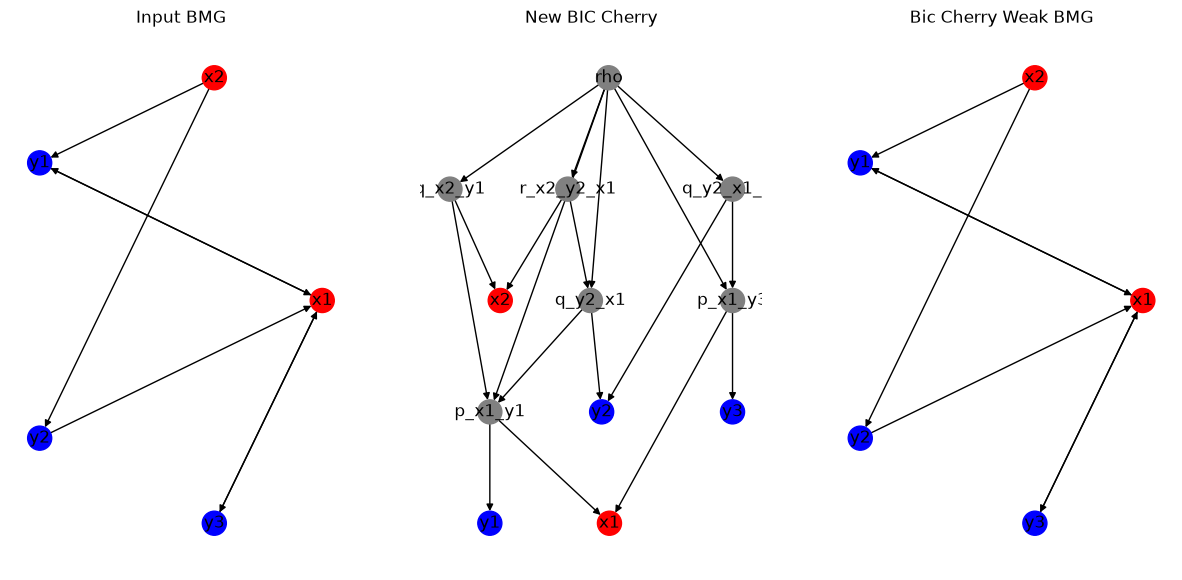

In [25]:
# figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
pos = graphviz_layout(bic_cherry, prog="dot")
nodes_list, nodes_colors = zip(*bic_cherry.nodes(data="color", default="grey"))
nx.draw(bic_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
axes[1].set_title("New BIC Cherry")

# weak bmg
#strong_bmg = bmg(test_graph, mode="strong")
pos = nx.circular_layout(test_BMG)
nodes_list, nodes_colors = zip(*test_BMG.nodes(data="color", default="grey"))
nx.draw(test_BMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Input BMG")

# bic cherry weak BMG
#weak_bmg = bmg(test_graph, mode="weak")
nx.draw(weak_bic_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True)
axes[2].set_title("Bic Cherry Weak BMG")

In [8]:
print(weak_bmg.edges())
print(weak_bmg.nodes())

[('x1', 'y1'), ('x2', 'y1'), ('y1', 'x2'), ('y2', 'x2')]
['x1', 'x2', 'y1', 'y2']


In [3]:
# creating the bic Cherry from the networks paper, figure 2 b
bic_cherry = nx.DiGraph()
bic_cherry.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("z", {"color": "red"})])
bic_cherry.add_edges_from([("rho", "Pxy"), ("Pxy", "y"), ("Pxy", "x"), ("Pxy", "Qxz"), ("Qxz", "x"), ("Qxz", "z"),
                           ("rho", "Pxz"), ("Pxz", "z"), ("Pxz", "x"), ("Pxz", "Qxy"), ("Qxy", "x"), ("Qxy", "y")])

Text(0.5, 1.0, 'Weak BMG')

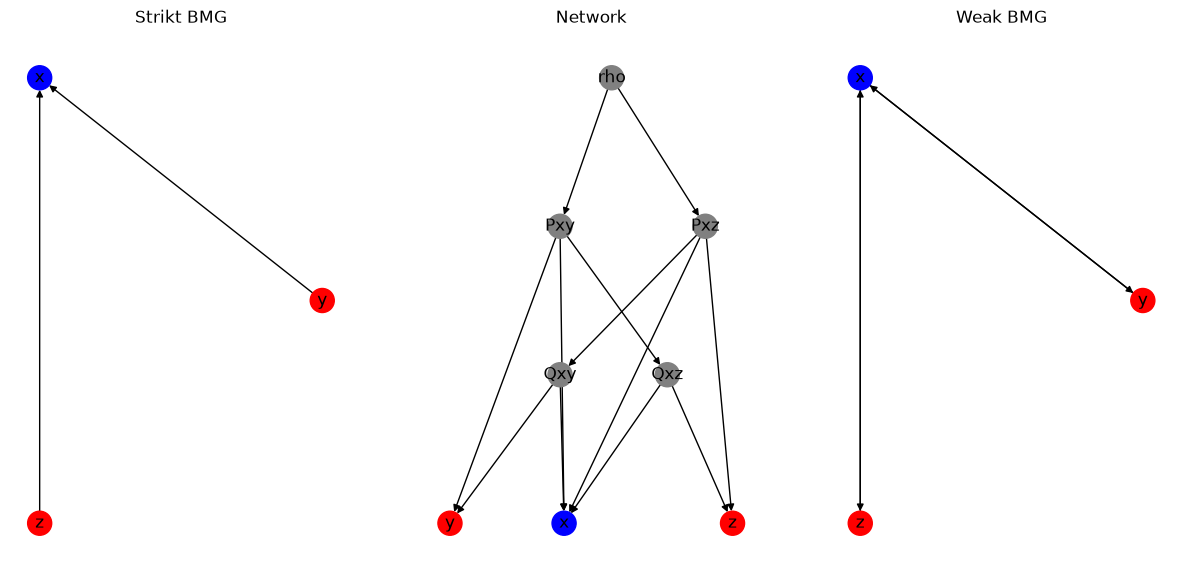

In [8]:
# figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
pos = graphviz_layout(bic_cherry, prog="dot")
nodes_list, nodes_colors = zip(*bic_cherry.nodes(data="color", default="grey"))
nx.draw(bic_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
axes[1].set_title("Network")

# strong bmg
strong_bmg = bmg(bic_cherry, mode="strong")
pos = nx.circular_layout(strong_bmg)
nodes_list, nodes_colors = zip(*strong_bmg.nodes(data="color", default="grey"))
nx.draw(strong_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Strikt BMG")

# weak BMG
weak_bmg = bmg(bic_cherry, mode="weak")
nx.draw(weak_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True)
axes[2].set_title("Weak BMG")

### Check if a modified version of the BIC-cherry + expansion procedure yields networks that explain weak best match graphs.

# Tasks

## Use `AsymmeTree` to generate trees. 
Modify the resulting trees by inserting hybridization vertices to generate phylogenetic networks (iteratively choosing two random points on edges of the tree/network and connecting them).

## Construction of explaining networks:
1. Implement the BIC-cherry+expansion algorithm for given graphs $(G, \sigma)$ as in the tech report from Patricia Ebert and Marc Hellmuth.
2. Modify this algorithm by restricting expansions $[xy : xz]$ to accepting edges $xz$ in graph $(G, \sigma)$ and possibly relabel $q_{xz}$ as $p_{xz}$
3. Thoroughly test these algorithms! Think of unit tests for your implementations!
4. Test if variant (b) always yields an explanation for weak best matches: to this end, generate a network $(N, \sigma)$, compute its weak best match graph, run variant (b) to produce an explaining network $(N', \sigma)$, and check that the weak best match graph of $(N', \sigma)$ coincides with the weak best match graph of $(N, \sigma)$. If this turns out to be not true, find the minimal examples where the networks differ.

## Simplification of explaining networks
1. Construct tree-BMGs $(G, \sigma)$ from (`AsymmeTree`-generated) trees and compute their least resolved trees $T∗$ . This is the target.
2. Take the tree-BMGs from (a) and construct the BIC-cherry+expansion explanations $(N, \sigma)$.
3. Implement graph editing by “pulling up” or “pulling down” edges, and removing vertices with the same parents and children, as described in class.
4. Check both for single moves and combinations of a small number of moves whether the modified network $(N', \sigma)$ has the same (weak) best match graph as $(N, \sigma)$.
5. Devise heuristics to search for edit paths that allow the stepwise conversion of the BIC-cherry+expansion explanations of (N, σ) in the least resolved tree-explanation (lrt) $T∗$.
6. If this is not always successful, find minimal examples that fail, try to find out why they fail, and if possible use this information to improve the heuristic for editing schedules.

# Interpretation
Try to find out why and where simple approaches fail (as e.g. in 2f) and make recommendation for further improvements/modifications.